In [33]:
import pandas as pd
import numpy as np
!pip install clean-text
from cleantext import clean
import re
from transformers import XLNetTokenizer,XLNetForSequenceClassification,TrainingArguments,Trainer,pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
!pip install evaluate
import random

In [34]:
#reading the datasets
data_train = pd.read_csv('emotion-labels-train.csv')
data_test = pd.read_csv('emotion-labels-test.csv')
data_val = pd.read_csv('emotion-labels-val.csv')

In [35]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [36]:
# cleaning the text by removing punctutations and emojis using cleantext lib
data = pd.concat([data_train,data_test,data_val],ignore_index=True)
data['clean_text'] = data['text'].apply(lambda x: clean(x,no_emoji=True,no_punct=True))
data.head()

,text,label,clean_text
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing garydelaney in bursl...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i dont...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,gardinerlove thank you so much gloria youre so...
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...


<Axes: xlabel='label'>

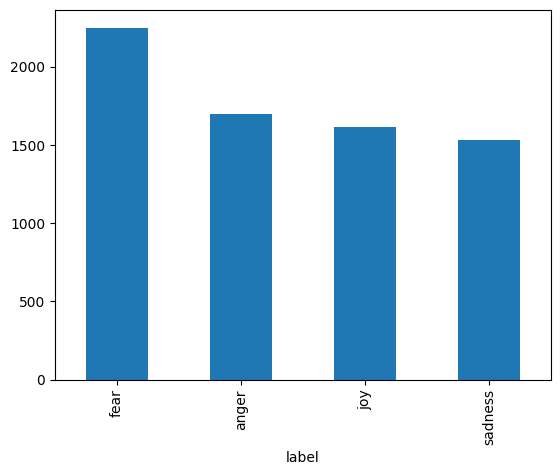

In [37]:
data['label'].value_counts().plot(kind='bar')

In [38]:
# smapling equal no.of data points of each label and dropping the old indices to avoid multi level indexing
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x : x.sample(g.size().min()).reset_index(drop=True)))

/tmp/ipykernel_147/3095673312.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = pd.DataFrame(g.apply(lambda x : x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

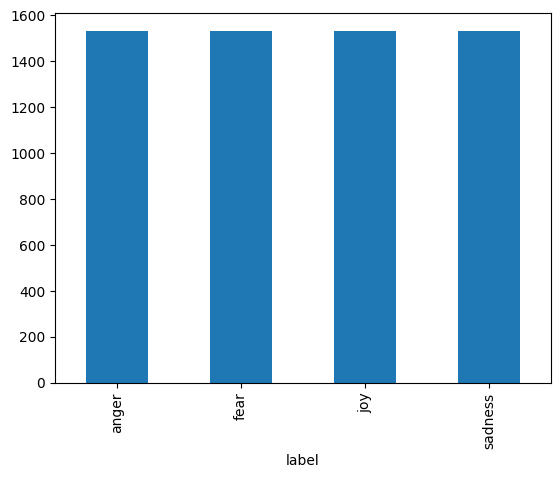

In [39]:
data['label'].value_counts().plot(kind='bar')

In [40]:
# converting labels into numeric labels using LabelEncoder
data['label_int'] = LabelEncoder().fit_transform(data['label'])
data.head()

text  label  \
label                                                               
anger 0  sixth form has destroyed my glowing skin im fu...  anger   
      1  be strong, independant and practical. stop liv...  anger   
      2  @daynutrition @sliqnicq @nytimes I don't liste...  anger   
      3  @sebbyD27850 both are nonsensical. If there's ...  anger   
      4  Michelle, who did NOTHING is hating on Nicole'...  anger   

                                                clean_text  label_int  
label                                                                  
anger 0  sixth form has destroyed my glowing skin im fu...          0  
      1  be strong independant and practical stop livin...          0  
      2  daynutrition sliqnicq nytimes i dont listen to...          0  
      3  sebbyd27850 both are nonsensical if theres inj...          0  
      4  michelle who did nothing is hating on nicoles ...          0

In [41]:
NUM_LABELS = 4

In [42]:
train_split,test_split = train_test_split(data,train_size=0.8)
train_split, val_split = train_test_split(train_split,train_size=0.9)
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [43]:
train_df = pd.DataFrame({
    "label" : train_split.label_int.values,
    "text" : train_split.clean_text.values
})

test_df = pd.DataFrame({
    "label" : test_split.label_int.values,
    "text" : test_split.clean_text.values
})

In [44]:
# converting pandas DataFrame into HuggingFace dataset using datasets lib
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

In [45]:
#Creating embeddings
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

def tokenize_func(inp):
  return tokenizer(inp["text"],padding="max_length",max_length=128,truncation=True)

In [46]:
tokenized_datasets = dataset_dict.map(tokenize_func,batched=True)
tokenized_datasets

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [47]:
print(tokenized_datasets['train']['text'][0])

cassidyyy0 literally nicole already had her chance and she played shitty both seasons


In [48]:
#input_ids: the numbers representing the tokens in the text.
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2349, 10598, 2087, 117, 117, 279, 7641, 17, 6962, 5457, 427, 54, 62, 1116, 21, 85, 507, 7341, 982, 207, 4026, 4, 3]


In [50]:
#token_type_ids: indicates which sequence a token belongs to if there is more than one sequence.
#attention_mask represents if mask should be applied to the token or not
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [51]:
tokenizer.decode(5)

'<pad>'

In [53]:
small_train_dataset = tokenized_datasets['train'].shuffle(seed=42).select(range(100))
small_test_dataset = tokenized_datasets['test'].shuffle(seed=42).select(range(100))